Biometric Technologies and Behavioural Security
# **<center>Tutorial 9 - Crowd Analysis and Blob detection</center>**
### **<center>Part 2: Face Mask Detector</center>**

##Step 1: Download Face Mask dataset and face detector files

This dataset consists of 1,376 images belonging to two classes:

* **with_mask**: 690 images
* **without_mask**: 686 images

In order to increase the generalizability of the model, the dataset is composed also by **augmented** images, that are the results of applying data augmentation to the original dataset.

In [ ]:
from IPython.display import clear_output
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

downloaded = drive.CreateFile({'id': '1eWw_sGrm1huHWWIjUHq8W0terltF4Gh_'})
downloaded.GetContentFile('dataset.zip')
!unzip dataset
clear_output()
print('Done! Press the Refresh button if files are not visible.')

Done! Press the Refresh button if files are not visible.


## Step 2: Train a classifier

This task can be done with a new type of network: the **MobileNet V2**. This is a highly efficient architecture that can be applied to embedded devices with limited computational capacity (ex., Raspberry Pi, Google Coral, NVIDIA Jetson Nano, etc.). If we deploy this face mask detector to embedded devices, the cost of manufacturing will be much less.

With the followin code, we import all the packages that we need and define the system parameters.

In [ ]:
# import the necessary packages
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
#from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import argparse
import os
import cv2

# initialize parameters
INIT_LR = 1e-4
EPOCHS = 5
BS = 32

At this point, we’re ready to load and pre-process the training data

In [ ]:

imagePaths = list(paths.list_images("/content/dataset"))
data = []
labels = []

# loop over the image paths
for imagePath in imagePaths:
	# extract the class label from the filename
	label = imagePath.split(os.path.sep)[-2]

	# load the input image (224x224) and preprocess it
	image = load_img(imagePath, target_size=(224, 224))
	image = img_to_array(image)
	image = preprocess_input(image)

	# update the data and labels lists, respectively
	data.append(image)
	labels.append(label)

# convert the data and labels to NumPy arrays
data = np.array(data, dtype="float32")
labels = np.array(labels)
print("Images loaded and preprocessed.")


Images loaded and preprocessed.


One-hot encode our class labels since we use a SoftMax as a final layer. You can find <a href = "https://stats.stackexchange.com/questions/233658/softmax-vs-sigmoid-function-in-logistic-classifier">here</a> an interesting explanation of why we use this instead of the sigmoid.

In [ ]:
# perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)
labels

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]], dtype=float32)

###Step 2.1 Fine-tuning classifier parameters

Fine-tuning setup is a three-step process:

1. Load MobileNet with pre-trained <a href="http://www.image-net.org/">ImageNet</a> weights, leaving off head of network;
2. Construct a new FC head, and append it to the base in place of the old head;
3. Freeze the base layers of the network. The weights of these base layers will not be updated during the process of backpropagation, whereas the head layer weights will be tuned.

In this snippet we are also setting a **<a href="https://towardsdatascience.com/learning-rate-schedules-and-adaptive-learning-rate-methods-for-deep-learning-2c8f433990d1">learning rate decay schedule</a>**, in order to adjust the learning rate during the training of the network.

In [ ]:
#split the dataset
(trainX, testX, trainY, testY) = train_test_split(data, labels,
	test_size=0.20, stratify=labels, random_state=42)

# load the MobileNetV2 network, ensuring the head FC layer sets are
# left off
baseModel = MobileNetV2(input_shape = (224,224,3), weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))

headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)

# place the head FC model on top of the base model (this will become
# the actual model we will train)
model = Model(inputs=baseModel.input, outputs=headModel)

# loop over all layers in the base model and freeze them so they will
# *not* be updated during the first training process
for layer in baseModel.layers:
	layer.trainable = False

# compile the model

opt = Adam(lr=INIT_LR, decay=INIT_LR / EPOCHS)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])

# train the head of the network
print("Training the model...")
H = model.fit(trainX, trainY, batch_size=BS,
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS)

# make predictions on the testing set
print(" ")
predIdxs = model.predict(testX, batch_size=BS)

# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)

# show classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/legacy/adam.py:118: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Training the model...
Epoch 1/5
34/34 [==============================] - 10s 102ms/step - loss: 0.5128 - accuracy: 0.8171 - val_loss: 0.2234 - val_accuracy: 0.9688
Epoch 2/5
34/34 [==============================] - 3s 53ms/step - loss: 0.1830 - accuracy: 0.9728 - val_loss: 0.1061 - val_accuracy: 0.9805
Epoch 3/5
34/34 [==============================] - 2s 61ms/step - loss: 0.1016 - accuracy: 0.9813 - val_loss: 0.0712 - val_accuracy: 0.9805
Epoch 4/5
34/34 [==============================] - 2s 52ms/step - loss: 0.0719 - accuracy: 0.9878 - val_loss: 0.0552 - val_accuracy: 0.9805
Epoch 5/5
34/34 [==============================] - 2s 52ms/step - loss: 0.0559 - accuracy: 0.9916 - val_loss: 0.0459 - val_accuracy: 0.9844
 
9/9 [==============================] - 2s 140ms/step
              precision    recall  f1-score   support

   with_mask       1.00      0.97      0.99       138
without_mask       0.97      1.00      0.99       138

    accuracy                           0.99       276
   

### Step 2.2 [Optional]: Plot accuracy

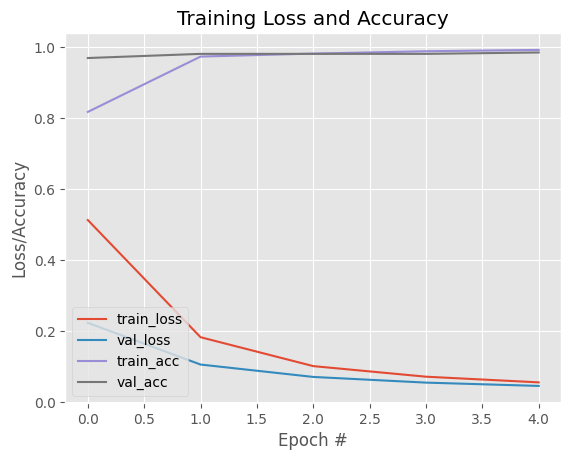

In [ ]:
# plot the training loss and accuracy
N = EPOCHS
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
plt.savefig("plot.png")

## Step 3: Test the model

### Step 3.1: Test images

[1] Loading face detector model...
[2] Detecting faces...
1/1 [==============================] - 0s 23ms/step


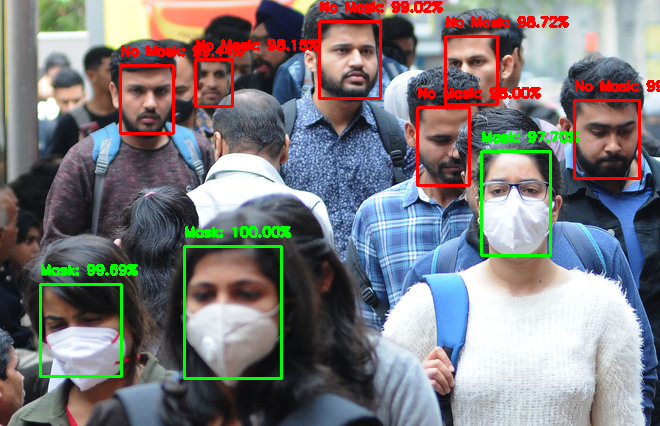

-1

In [ ]:

# load serialized face detector model
print("[1] Loading face detector model...")
prototxtPath = "/content/face_detector/deploy.prototxt"
weightsPath =  "/content/face_detector/res10_300x300_ssd_iter_140000.caffemodel"
net = cv2.dnn.readNet(prototxtPath, weightsPath)


# load the input image
image = cv2.imread("/content/example.jpg")
orig = image.copy()
(h, w) = image.shape[:2]

# construct a blob from the image
blob = cv2.dnn.blobFromImage(image, 1.0, (300, 300),
	(104.0, 177.0, 123.0))

# pass the blob through the network and obtain the face detections
print("[2] Detecting faces...")
net.setInput(blob)
detections = net.forward()

# loop over the detections
for i in range(0, detections.shape[2]):
	# extract the confidence (i.e., probability) associated with
	# the detection
	confidence = detections[0, 0, i, 2]

	# filter out weak detections by ensuring the confidence is
	# greater than the minimum confidence
	if confidence > 0.5:
		# compute the (x, y)-coordinates of the bounding box for
		# the object
		box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
		(startX, startY, endX, endY) = box.astype("int")

		# ensure the bounding boxes fall within the dimensions of
		# the frame
		(startX, startY) = (max(0, startX), max(0, startY))
		(endX, endY) = (min(w - 1, endX), min(h - 1, endY))

		# extract the face ROI, convert it from BGR to RGB channel
		# ordering, resize it to 224x224, and preprocess it
		face = image[startY:endY, startX:endX]
		face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
		face = cv2.resize(face, (224, 224))
		face = img_to_array(face)
		face = preprocess_input(face)
		face = np.expand_dims(face, axis=0)

		# pass the face through the model to determine if the face
		# has a mask or not
		(mask, withoutMask) = model.predict(face)[0]

		# determine the class label and color we'll use to draw
		# the bounding box and text
		label = "Mask" if mask > withoutMask else "No Mask"
		color = (0, 255, 0) if label == "Mask" else (0, 0, 255)

		# include the probability in the label
		label = "{}: {:.2f}%".format(label, max(mask, withoutMask) * 100)

		# display the label and bounding box rectangle on the output
		# frame
		cv2.putText(image, label, (startX, startY - 10),
			cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 2)
		cv2.rectangle(image, (startX, startY), (endX, endY), color, 2)


from google.colab.patches import cv2_imshow
# show the output image
cv2_imshow(image)
cv2.waitKey(0)

### Step 3.1: Test video stream

The algorithm for this script is the same, but it is pieced together in such a way to allow for processing every frame of your webcam stream.

Thus, the only difference when it comes to imports is that we need a VideoStream class and time. Both of these will help us to work with the stream. We’ll also take advantage of imutils for its aspect-aware resizing method.

In [ ]:
import imutils
from imutils.video import VideoStream

def detect_and_predict_mask(frame, faceNet, maskNet):
	# grab the dimensions of the frame and then construct a blob
	# from it
	(h, w) = frame.shape[:2]
	blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300),
		(104.0, 177.0, 123.0))

	# pass the blob through the network and obtain the face detections
	faceNet.setInput(blob)
	detections = faceNet.forward()

	# initialize our list of faces, their corresponding locations,
	# and the list of predictions from our face mask network
	faces = []
	locs = []
	preds = []

	# loop over the detections
	for i in range(0, detections.shape[2]):
		# extract the confidence (i.e., probability) associated with
		# the detection
		confidence = detections[0, 0, i, 2]

		# filter out weak detections by ensuring the confidence is
		# greater than the minimum confidence
		if confidence > 0.5:
			# compute the (x, y)-coordinates of the bounding box for
			# the object
			box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
			(startX, startY, endX, endY) = box.astype("int")

			# ensure the bounding boxes fall within the dimensions of
			# the frame
			(startX, startY) = (max(0, startX), max(0, startY))
			(endX, endY) = (min(w - 1, endX), min(h - 1, endY))

			# extract the face ROI, convert it from BGR to RGB channel
			# ordering, resize it to 224x224, and preprocess it
			face = frame[startY:endY, startX:endX]
			face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
			face = cv2.resize(face, (224, 224))
			face = img_to_array(face)
			face = preprocess_input(face)
			face = np.expand_dims(face, axis=0)

			# add the face and bounding boxes to their respective
			# lists
			locs.append((startX, startY, endX, endY))

	# only make a predictions if at least one face was detected
	if len(faces) > 0:
		# for faster inference we'll make batch predictions on *all*
		# faces at the same time rather than one-by-one predictions
		# in the above `for` loop
		print(faces)
		preds = maskNet.predict(faces)

	# return a 2-tuple of the face locations and their corresponding
	# locations
	return (locs, preds)

Since Colab is running in a browser, we have to use web APIs to access local hardware like a camera. The following code can help us to do it.

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
from PIL import Image
import io
import time


def VideoCapture():
  js = Javascript('''
    async function create(){
      div = document.createElement('div');
      document.body.appendChild(div);

      video = document.createElement('video');
      video.setAttribute('playsinline', '');

      div.appendChild(video);

      stream = await navigator.mediaDevices.getUserMedia({video: {facingMode: "environment"}});
      video.srcObject = stream;

      await video.play();

      canvas =  document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      div_out = document.createElement('div');
      document.body.appendChild(div_out);
      img = document.createElement('img');
      div_out.appendChild(img);

    }

    async function capture(){
        return await new Promise(function(resolve, reject){
            pendingResolve = resolve;
            canvas.getContext('2d').drawImage(video, 0, 0);
            result = canvas.toDataURL('image/jpeg', 0.8);
            pendingResolve(result);
        })
    }

    function showimg(imgb64){
        img.src = "data:image/jpg;base64," + imgb64;
    }

  ''')
  display(js)

def byte2image(byte):
  jpeg = b64decode(byte.split(',')[1])
  im = Image.open(io.BytesIO(jpeg))
  return np.array(im)

def image2byte(image):
  image = Image.fromarray(image)
  buffer = io.BytesIO()
  image.save(buffer, 'jpeg')
  buffer.seek(0)
  x = b64encode(buffer.read()).decode('utf-8')
  return x



Final stage. Read and submit each frame to the detector in order to make a prediction. As we just saw, Colab runs on a server, so the frame processing is a little bit slower than the webcam stream. Be patient.

In [ ]:
# load our serialized face detector model from disk
print("[1] Loading face detector model...")
prototxtPath = "/content/face_detector/deploy.prototxt"
weightsPath =  "/content/face_detector/res10_300x300_ssd_iter_140000.caffemodel"
faceNet = cv2.dnn.readNet(prototxtPath, weightsPath)


# initialize the video stream and allow the camera sensor to warm up
print("[2] Starting video stream...")
VideoCapture()
eval_js('create()')

time.sleep(2.0)

# loop over the frames from the video stream
while True:


  byte = eval_js('capture()')
  im = byte2image(byte)
  frame = imutils.resize(im, width=400)

  (locs, preds) = detect_and_predict_mask(frame, faceNet, model)

  # loop over the detected face locations
  for (box, pred) in zip(locs, preds):

   		# unpack the bounding box and predictions
      (startX, startY, endX, endY) = box
      (mask, withoutMask) = pred

      # determine the class label and bounding box color
      label = "Mask" if mask > withoutMask else "No Mask"
      color = (0, 255, 0) if label == "Mask" else (255, 0, 0)

      # include the probability in the label
      label = "{}: {:.2f}%".format(label, max(mask, withoutMask) * 100)

      # display the label and bounding box rectangle on the output frame
      cv2.putText(frame, label, (startX, startY - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 2)
      cv2.rectangle(frame, (startX, startY), (endX, endY), color, 2)

      # show the output frame
      eval_js('showimg("{}")'.format(image2byte(frame)))



[1] Loading face detector model...
[2] Starting video stream...


<IPython.core.display.Javascript object>

[array([[[[-0.08235294, -0.04313725, -0.01176471],
         [-0.05882353, -0.01960784,  0.01176476],
         [-0.02745098,  0.00392163,  0.04313731],
         ...,
         [ 0.22352946,  0.23921573,  0.1686275 ],
         [ 0.22352946,  0.23921573,  0.18431377],
         [ 0.22352946,  0.23921573,  0.19215691]],

        [[-0.06666666, -0.00392157,  0.0196079 ],
         [-0.03529412,  0.02745104,  0.05098045],
         [ 0.01176476,  0.06666672,  0.09019613],
         ...,
         [ 0.19215691,  0.2313726 ,  0.15294123],
         [ 0.19215691,  0.22352946,  0.17647064],
         [ 0.19215691,  0.21568632,  0.18431377]],

        [[-0.03529412,  0.02745104,  0.05098045],
         [-0.01176471,  0.05098045,  0.07450986],
         [ 0.02745104,  0.082353  ,  0.10588241],
         ...,
         [ 0.1686275 ,  0.22352946,  0.14509809],
         [ 0.17647064,  0.20784318,  0.1686275 ],
         [ 0.17647064,  0.20000005,  0.18431377]],

        ...,

        [[ 0.45882356,  0.43529415,  

KeyboardInterrupt: 